In [1]:
# Load dependencies
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from create_split import create_split
from plot_fitness_landscape import visualize_fitness_landscape

import mavenn

2026-02-20 15:08:41.282840: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Load TF-Bind-8 Data

In [2]:
# Load dataset
#df = pd.read_csv('../tf_bind_8-SIX6_REF_R1/dataset.csv')
df = mavenn.load_example_dataset('gb1')
df = df[['y', 'x']]
df.columns = ['binding_scores', 'sequence']
df['split'] = ['None'] * len(df)

print("Dataset loaded with shape:", df.shape)

df.head()

Dataset loaded with shape: (530737, 3)


,binding_scores,sequence,split
0,-3.145154,AAKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,None
1,-1.867676,ACKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,None
2,-5.270800,ADKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,None
3,-5.979498,AEKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,None
4,0.481923,AFKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,None


In [3]:
df = create_split(
    df,
    k_seeds=50,
    n_training_seeds=20,
    train_fraction=0.7,
    test_a_fraction=0.10,
    test_b_fraction=0.10,
    test_c_fraction=0.10,
    fitness_percentile_cutoff=50.0,
    training_radius_percentile=20.0,
    random_state=42,
    )
df.head()


,binding_scores,sequence,split,cluster,distance_to_seed
0,-3.145154,AAKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,test_c,0,4
1,-1.867676,ACKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,test_c,0,4
2,-5.270800,ADKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,test_c,0,4
3,-5.979498,AEKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,test_c,0,4
4,0.481923,AFKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...,test_c,0,4


In [4]:
np.unique(df.cluster.values, return_counts=True)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]),
 array([75698, 15086, 29031, 29394,  2280, 23306, 14419, 12507, 12642,
        24046, 24857, 22690,  2220, 13010, 12641,  2182, 13179, 12341,
        22322, 12023, 11153, 15221,  2125, 10254, 10042,  1925,  2106,
         2173,  1206,  1868,  1257, 17657,  1885,  9497,  2124,  8785,
         2067,  8238,  8561,  1870,  2035,  8169,  1816,  2073,  7947,
         1240,  1898,  1069,  1112,  7490]))

In [5]:
# list unique clusters in each split
df.groupby('split')['cluster'].unique()

split
test_a    [25, 19, 39, 4, 37, 48, 17, 3, 15, 41, 45, 46,...
test_b                        [19, 17, 3, 6, 41, 13, 8, 37]
test_c    [0, 49, 24, 35, 10, 43, 2, 21, 34, 31, 18, 1, ...
train     [37, 25, 48, 39, 17, 41, 15, 4, 3, 46, 26, 6, ...
Name: cluster, dtype: object

split
test_c    399457
test_b     93328
train      21218
test_a     16734
Name: count, dtype: int64


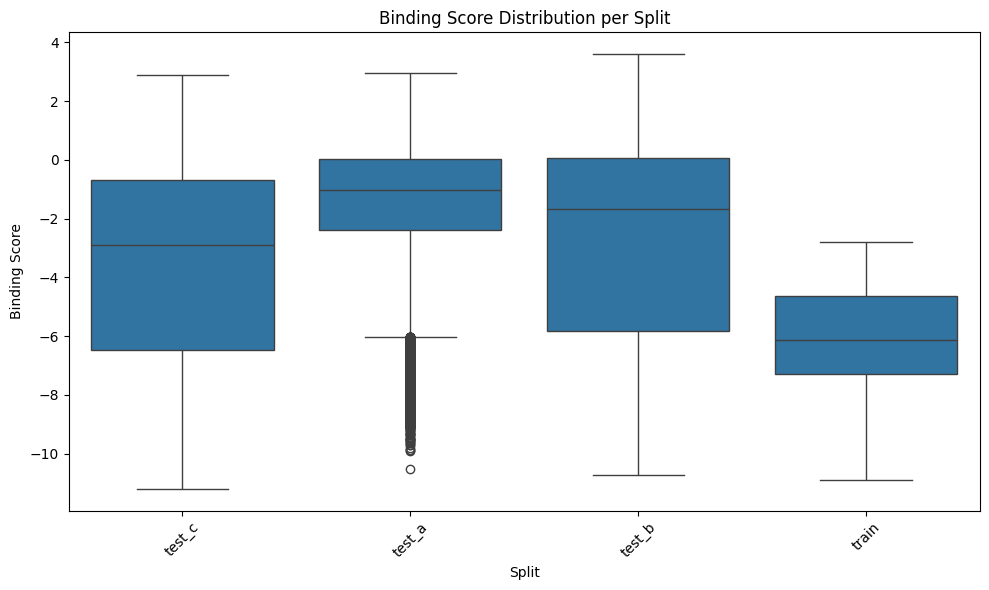

In [6]:
# Basic statistics of the splits
print(df['split'].value_counts())

# binding score distribution per split

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='split', y='binding_scores')
plt.title('Binding Score Distribution per Split')
plt.xlabel('Split')
plt.ylabel('Binding Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Fitness Landscape Visualization

1. Dataset info: 530737 sequences
   Split distribution:
     train       :  21218 ( 4.00%)
     test_a      :  16734 ( 3.15%)
     test_b      :  93328 (17.58%)
     test_c      : 399457 (75.26%)
     unused      :      0 ( 0.00%)

2. Encoding sequences (one-hot)...
   Encoded shape: (530737, 220)

3. Loading cached 2D projection from assets/umap_n530737_seed42.pkl...
   Loaded projection shape: (530737, 2)

4. Generating plots...

   Plot 1: Fitness Landscape (Scatter)
Saved fitness landscape plot to fitness_landscape_scatter.png


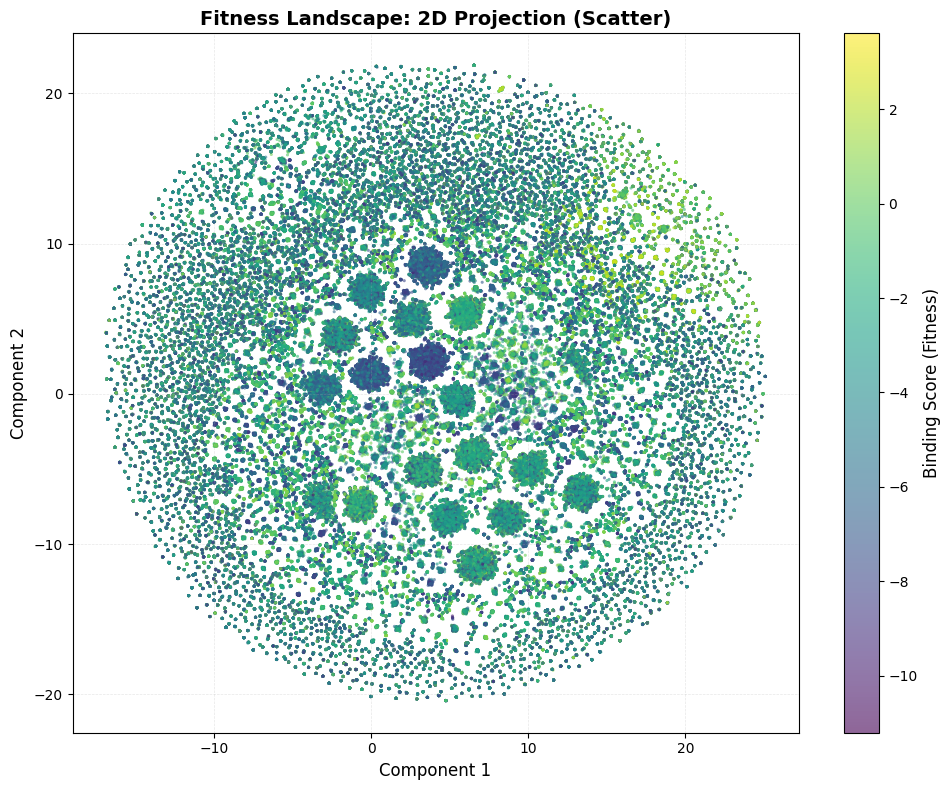


   Plot 2: Fitness Landscape (Contour)
Saved fitness landscape plot to fitness_landscape_contour.png


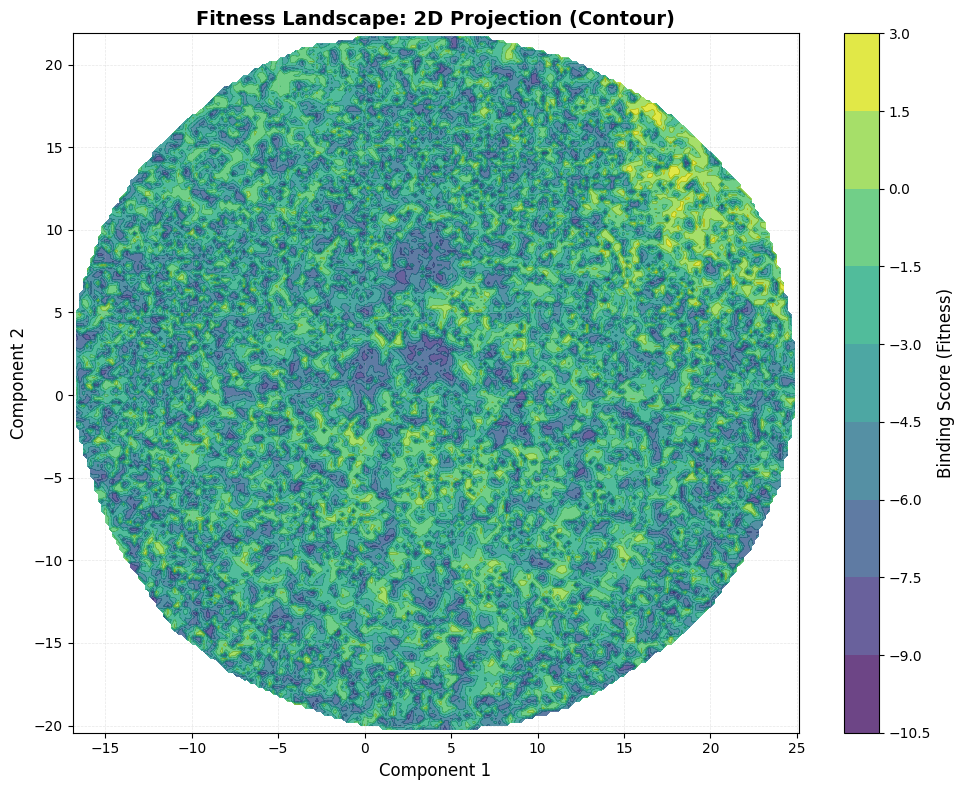


   Plot 3: Split Validation
Saved split validation plot to split_validation.png


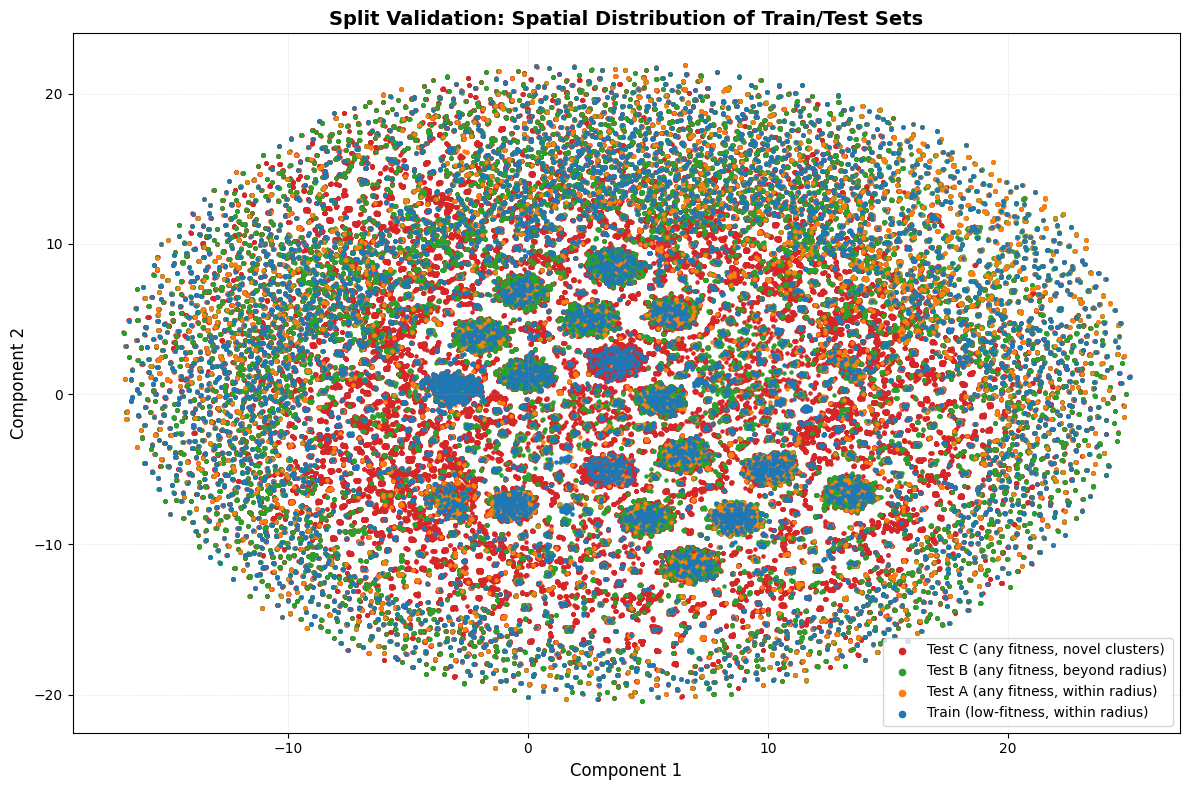


   Plot 4: Split Statistics


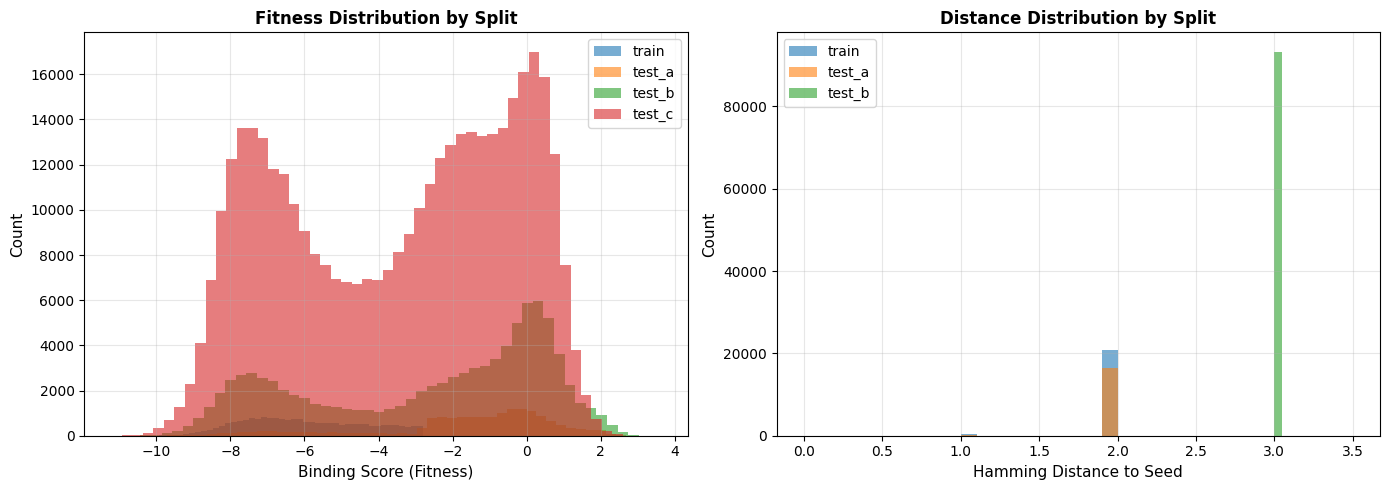


Visualization complete!


(        binding_scores                                           sequence  \
 0            -3.145154  AAKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...   
 1            -1.867676  ACKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...   
 2            -5.270800  ADKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...   
 3            -5.979498  AEKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...   
 4             0.481923  AFKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...   
 ...                ...                                                ...   
 530732       -2.515259  QYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...   
 530733       -2.693165  QYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...   
 530734       -2.896589  QYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...   
 530735       -3.150861  QYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...   
 530736       -3.287173  QYKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDD...   
 
          split  cluster  distance_to_seed  
 0       test_c  

In [7]:
# make sure the correct embeddings are created (mind hyperparameters!!!!)
visualize_fitness_landscape(df,
                            projection_method='umap',
                            save_plots=True,
                            )